## The goal here is to check if the distribution of values in the test set align with the training data

In [1]:
OLDER_MACHINE = False

BONE = 'radius'

COMPARE_USABLE = True # compare whether data distributon of good vs bad scans is similar or if something sticks out

BALANCED_MODEL = True # use weighted model

In [2]:
import pandas as pd
import numpy as np
from binarize_grades import binarize_grades
from sklearn.preprocessing import StandardScaler
from read_predictions import get_all_predictions
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

In [ ]:
raw_motion_data = pd.read_excel("data/Motion full matched_for_olga.xlsx", header=1)
motion_data = raw_motion_data.replace('-', np.nan)

radius_columns = ['Tt.BMD', 'Tt.Ar', 'Tb.BMD', 'BV/TV', 'Tb.N', 'Tb.Th', 'Tb.Sp', 'Tb.1/N.SD', 'Tb.Ar', 'Ct.BMD', 'Ct.Th', 'Ct.Po', 'Ct.Po.Dm', 'Ct.Pm', 'Ct.Ar']

if OLDER_MACHINE:
    # remove all rows where Ct.Po and Ct.Po.Dm are present
    motion_data = motion_data[motion_data['Ct.Po'].isna()]
    radius_columns.remove('Ct.Po')
    radius_columns.remove('Ct.Po.Dm')

tibia_columns = [f"{x}.1" for x in radius_columns]

motion_data[radius_columns] = motion_data[radius_columns].astype(float)
motion_data[tibia_columns] = motion_data[tibia_columns].astype(float)
motion_data[tibia_columns].head()

# drop NaN rows
motion_data = motion_data.dropna(subset=radius_columns + tibia_columns)

if BONE == 'radius':
    bone_columns = radius_columns
    train_data = motion_data[radius_columns]
else:
    bone_columns = tibia_columns
    train_data = motion_data[tibia_columns]

train_data

In [4]:
if COMPARE_USABLE:
    # compare scans that are bad with scans that are good
    grader_column = f'MG_{BONE}_rounded mean no Miki'
    # add column that combines the two other graders via a mean
    graders = ['Alex', 'Felix']
    if BONE == 'tibia':
        graders = [f"{x}.1" for x in graders]
    motion_data[grader_column] = motion_data[graders].mean(axis=1)
    motion_data[grader_column] = motion_data[grader_column].round()
    motion_data[grader_column] = motion_data[grader_column].astype(int)

    grades = motion_data[grader_column]
    motion_data = motion_data[radius_columns] if BONE == 'radius' else motion_data[tibia_columns]
    motion_data, zero_center, one_center = binarize_grades(motion_data, grades, return_centers=True)
    print(motion_data['cluster'].value_counts())
    grade_col_name = 'cluster'

    scaler = StandardScaler()
    scaled_motion_data = scaler.fit_transform(motion_data[bone_columns])
    motion_data[bone_columns] = scaled_motion_data

    predictions = pd.read_csv(f"predictions/{BONE}_{'' if OLDER_MACHINE else 'new_'}{'balanced_' if BALANCED_MODEL else ''}predictions.csv")
    motion_data['LogReg log-odds'] = predictions['logits'].to_list()

    usable_data = motion_data[motion_data[grade_col_name] == 0]
    unusable_data = motion_data[motion_data[grade_col_name] == 1]

    # filter to the bone columns
    if BONE == 'radius':
        radius_columns.append('LogReg log-odds')
    else:
        tibia_columns.append('LogReg log-odds')
    usable_data = usable_data[radius_columns] if BONE == 'radius' else usable_data[tibia_columns]
    unusable_data = unusable_data[radius_columns] if BONE == 'radius' else unusable_data[tibia_columns]

    print(f"Usable data shape: {usable_data.shape}")
    print(f"Unusable data shape: {unusable_data.shape}")

Cluster 0: 358
Cluster 1: 91
Unassigned: 51
cluster
0    400
1    100
Name: count, dtype: int64
Usable data shape: (400, 16)
Unusable data shape: (100, 16)


## Show data distribution per XCT

In [5]:
data = pd.read_excel("data/Motion full matched_for_olga.xlsx", header=1)
pred_cols_radius = ['Tt.BMD', 'Tt.Ar', 'Tb.BMD', 'BV/TV', 'Tb.N', 'Tb.Th', 'Tb.Sp', 'Tb.1/N.SD', 'Tb.Ar', 'Ct.BMD', 'Ct.Th', 'Ct.Po', 'Ct.Po.Dm', 'Ct.Pm', 'Ct.Ar']
pred_cols_tibia = [f"{x}.1" for x in pred_cols_radius]
data = data.replace('-', np.nan)
# stack radius and tibia columns
stacked_cols = []
bone_labels = []
for c1, c2 in zip(pred_cols_radius, pred_cols_tibia):
    stacked = pd.concat([data[c1], data[c2]], ignore_index=True)
    stacked_cols.append(stacked)

    bone = pd.Series(['radius'] * len(data) + ['tibia'] * len(data))

data_orig = pd.concat(stacked_cols, axis=1)
data_orig.columns = pred_cols_radius
data_orig['XCT'] = data_orig['Ct.Po'].apply(lambda x: 'XCT1' if pd.isna(x) else 'XCT2')
data_orig['bone'] = bone

all_preds = get_all_predictions()
all_preds = all_preds[['logits', 'model', 'balanced', 'true']].dropna()
all_preds = all_preds[all_preds['balanced'] == True]
all_preds['XCT'] = all_preds['model'].apply(lambda x: x.split(' ')[1])
all_preds['bone'] = all_preds['model'].apply(lambda x: x.split(' ')[0])
all_preds = all_preds.rename(columns={'logits': 'LogReg log-odds'})
all_preds['true'] = all_preds['true'].apply(lambda x: 'usable' if x == 'pass' else 'unusable')
all_preds = all_preds[['LogReg log-odds', 'XCT', 'true', 'bone']]
all_preds

/tmp/ipykernel_3359338/2702425409.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace('-', np.nan)


,LogReg log-odds,XCT,true,bone
2000,-0.774877,XCT1,usable,Tibia
2001,1.404754,XCT1,usable,Tibia
2002,4.456714,XCT1,unusable,Tibia
2003,-0.490175,XCT1,usable,Tibia
2004,-3.118239,XCT1,usable,Tibia
...,...,...,...,...
3995,-2.042178,XCT2,usable,Radius
3996,-2.184480,XCT2,usable,Radius
3997,-0.706877,XCT2,usable,Radius
3998,-1.811273,XCT2,usable,Radius


In [ ]:
# merge all_preds with data_filtered on XCT
data_filtered = data_orig.copy()
log_odds = []
usability = []
# THIS WORKS ONLY BECAUSE THE INDEX ORDERS HERE ARE THE SAME AS IN data_orig
for combination in [('XCT1', 'radius'), ('XCT2', 'radius'), ('XCT1', 'tibia'), ('XCT2', 'tibia')]:
    xct, bone = combination
    # get indices from data_orig
    indices = data_orig[(data_orig['XCT'] == xct) & (data_orig['bone'] == bone)].index
    log_odds.extend(all_preds[(all_preds['XCT'] == xct) & (all_preds['bone'] == bone.capitalize())]['LogReg log-odds'].values)
    usability.extend(all_preds[(all_preds['XCT'] == xct) & (all_preds['bone'] == bone.capitalize())]['true'].values)

data_filtered['LogReg log-odds'] = pd.Series(log_odds)
data_filtered['usability'] = pd.Series(usability)
data_filtered

In [7]:
def score_simple(row):
    # apply the following formula:
    # 2.459 \cdot \left( \frac{\text{Tb.N} - 1.414}{0.354} \right) +
    # 2.544 \cdot \left( \frac{\text{Tb.1/N.SD} - 0.414}{0.406} \right) -
    # 2.086 \cdot \left( \frac{\text{Tb.Sp} - 0.76}{0.377} \right) -
    # 1.758 \cdot \left( \frac{\text{BV/TV} - 0.152}{0.043} \right)

    score = 2.459 * ((row['Tb.N'] - 1.414) / 0.354) + \
           2.544 * ((row['Tb.1/N.SD'] - 0.414) / 0.406) - \
           2.086 * ((row['Tb.Sp'] - 0.76) / 0.377) - \
           1.758 * ((row['BV/TV'] - 0.152) / 0.043)
    return score

def score_by_xct(row):
    # for xct1:
    # 3.214 \cdot \left( \frac{\text{Tb.N} - 1.636}{0.419} \right) -
    # 1.839 \cdot \left( \frac{\text{Tb.Sp} - 0.601}{0.281} \right) -
    # 1.369 \cdot \left( \frac{\text{BV/TV} - 0.115}{0.031} \right) +
    # 2.553 \cdot \left( \frac{\text{Tb.1/N.SD} - 0.363}{0.368} \right)

    if row['XCT'] == 'XCT1':
        score = 3.214 * ((row['Tb.N'] - 1.636) / 0.419) - \
               1.839 * ((row['Tb.Sp'] - 0.601) / 0.281) - \
               1.369 * ((row['BV/TV'] - 0.115) / 0.031) + \
               2.553 * ((row['Tb.1/N.SD'] - 0.363) / 0.368)
    else:
        # for xct2:
        # 2.718 \cdot \left( \frac{\text{Tb.N} - 1.177}{0.287} \right) -
        # 2.368 \cdot \left( \frac{\text{Tb.Sp} - 0.919}{0.473} \right) -
        # 3.019 \cdot \left( \frac{\text{BV/TV} - 0.195}{0.055} \right) +
        # 2.481 \cdot \left( \frac{\text{Tb.1/N.SD} - 0.474}{0.482} \right)
        score = 2.718 * ((row['Tb.N'] - 1.177) / 0.287) - \
               2.368 * ((row['Tb.Sp'] - 0.919) / 0.473) - \
               3.019 * ((row['BV/TV'] - 0.195) / 0.055) + \
               2.481 * ((row['Tb.1/N.SD'] - 0.474) / 0.482)
    return score


In [8]:
data_filtered['CombinedScore'] = data_filtered.apply(score_simple, axis=1)
data_filtered['ScoreByXCT'] = data_filtered.apply(score_by_xct, axis=1)

['Tt.BMD', 'Tt.Ar', 'Tb.BMD', 'BV/TV', 'Tb.N', 'Tb.Th', 'Tb.Sp', 'Tb.1/N.SD', 'Tb.Ar', 'Ct.BMD', 'Ct.Th', 'Ct.Pm', 'Ct.Ar']


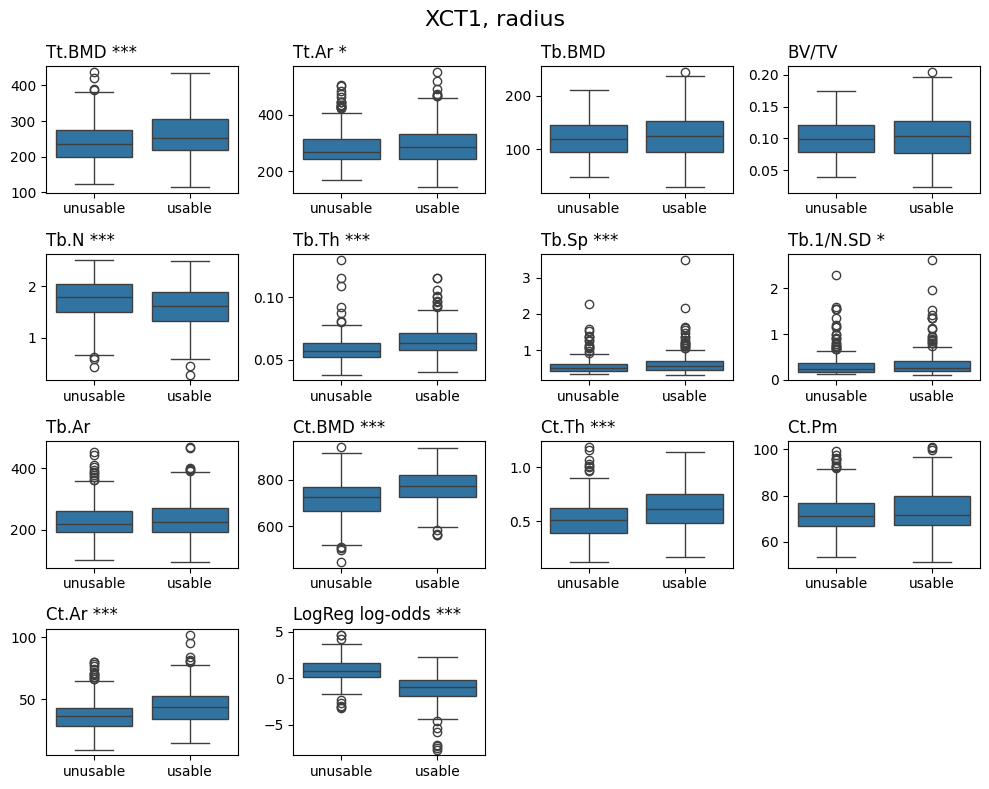

['Tt.BMD', 'Tt.Ar', 'Tb.BMD', 'BV/TV', 'Tb.N', 'Tb.Th', 'Tb.Sp', 'Tb.1/N.SD', 'Tb.Ar', 'Ct.BMD', 'Ct.Th', 'Ct.Pm', 'Ct.Ar']


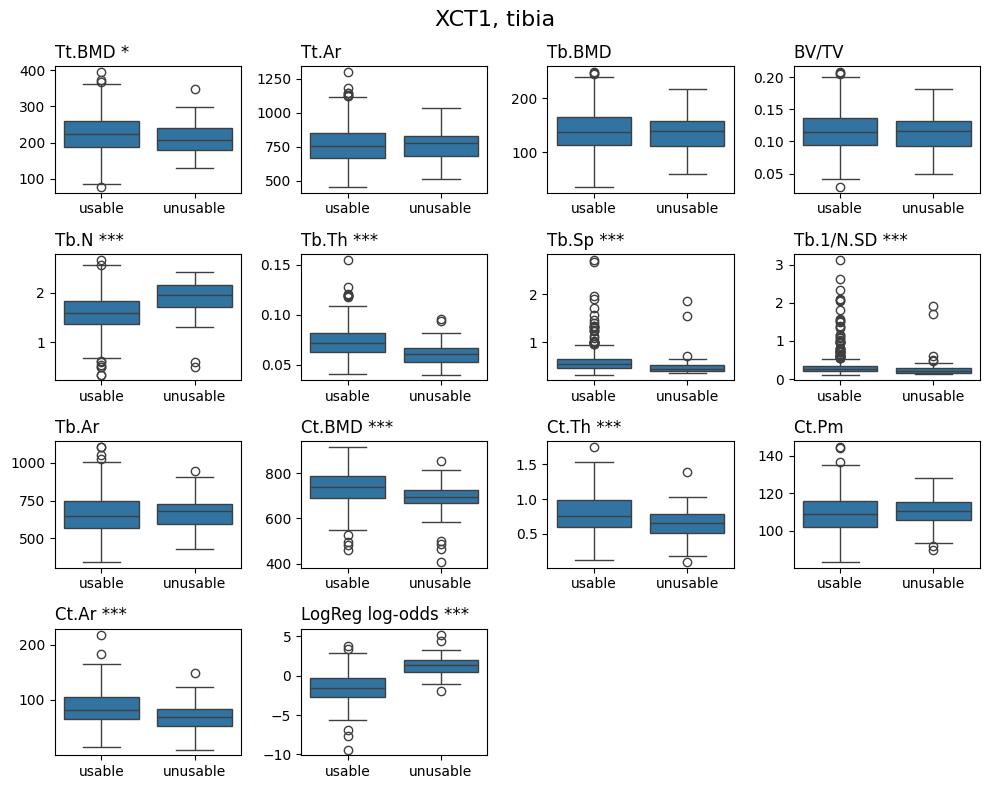

['Tt.BMD', 'Tt.Ar', 'Tb.BMD', 'BV/TV', 'Tb.N', 'Tb.Th', 'Tb.Sp', 'Tb.1/N.SD', 'Tb.Ar', 'Ct.BMD', 'Ct.Th', 'Ct.Po', 'Ct.Po.Dm', 'Ct.Pm', 'Ct.Ar']


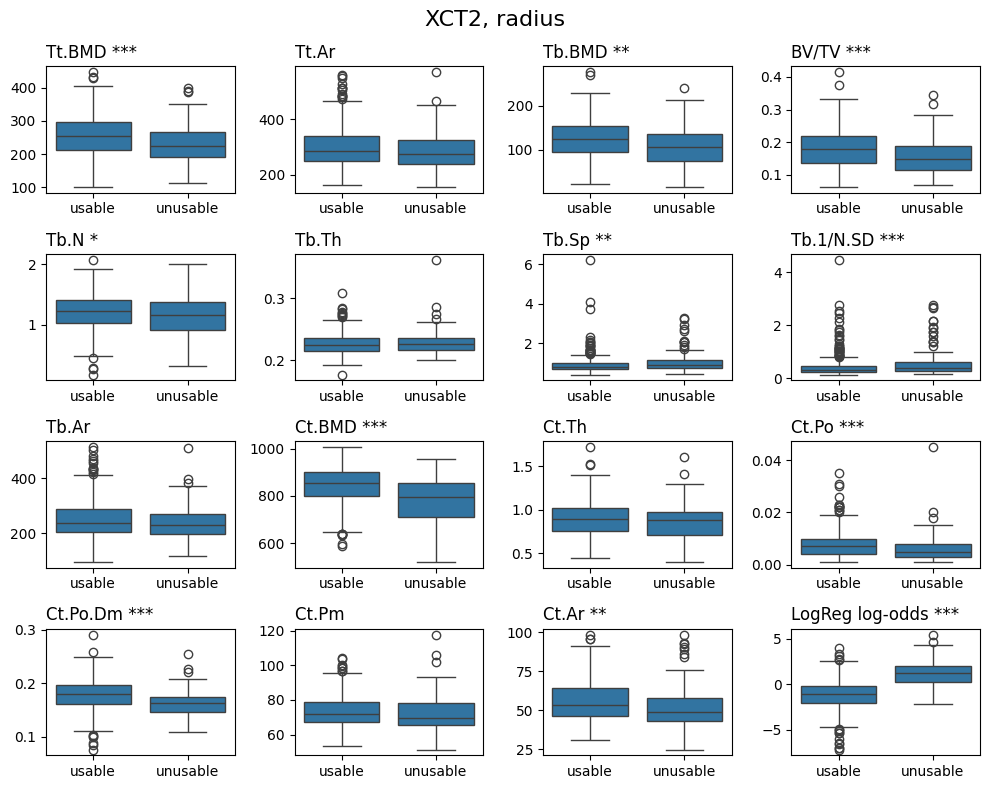

['Tt.BMD', 'Tt.Ar', 'Tb.BMD', 'BV/TV', 'Tb.N', 'Tb.Th', 'Tb.Sp', 'Tb.1/N.SD', 'Tb.Ar', 'Ct.BMD', 'Ct.Th', 'Ct.Po', 'Ct.Po.Dm', 'Ct.Pm', 'Ct.Ar']


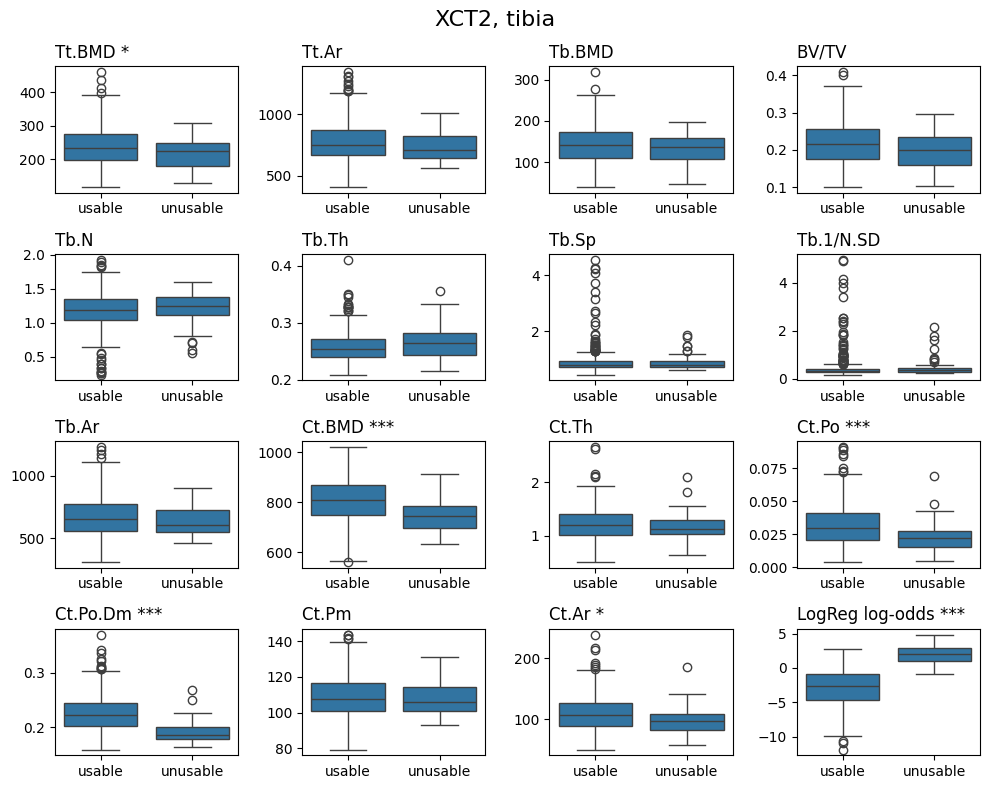

In [9]:
for xct in data_filtered['XCT'].unique():
    for bone in data_filtered['bone'].unique():
        data_xct = data_filtered[(data_filtered['XCT'] == xct) & (data_filtered['bone'] == bone)]
        fig = plt.figure(figsize=(10, 8))
        # if xct1, skip Ct.Po and Ct.Po.Dm
        if xct == 'XCT1':
            # copy pred_cols_radius and remove Ct.Po and Ct.Po.Dm
            pred_cols = pred_cols_radius.copy()
            pred_cols.remove('Ct.Po')
            pred_cols.remove('Ct.Po.Dm')

        else:
            pred_cols = pred_cols_radius
        print(pred_cols)
        for i, col in enumerate(pred_cols + ['LogReg log-odds',]):
            if data_xct[col].isna().all():
                continue
            ax = fig.add_subplot(4, 4, i+1)
            _, p = mannwhitneyu(data_xct[data_xct['usability'] == 'usable'][col], data_xct[data_xct['usability'] == 'unusable'][col])
            # check class of p
            if p > 0.05:
                p_str = ""
            elif p > 0.01:
                p_str = "*"
            elif p > 0.001:
                p_str = "**"
            else:
                p_str = "***"
            sns.boxplot(x='usability', y=col, data=data_xct)
            ax.set_ylabel("")
            ax.set_xlabel("")
            ax.set_title(f"{col} {p_str}", loc='left')
        # set overarching title
        plt.suptitle(f"{xct}, {bone}", fontsize=16)
        plt.tight_layout()
        plt.show()

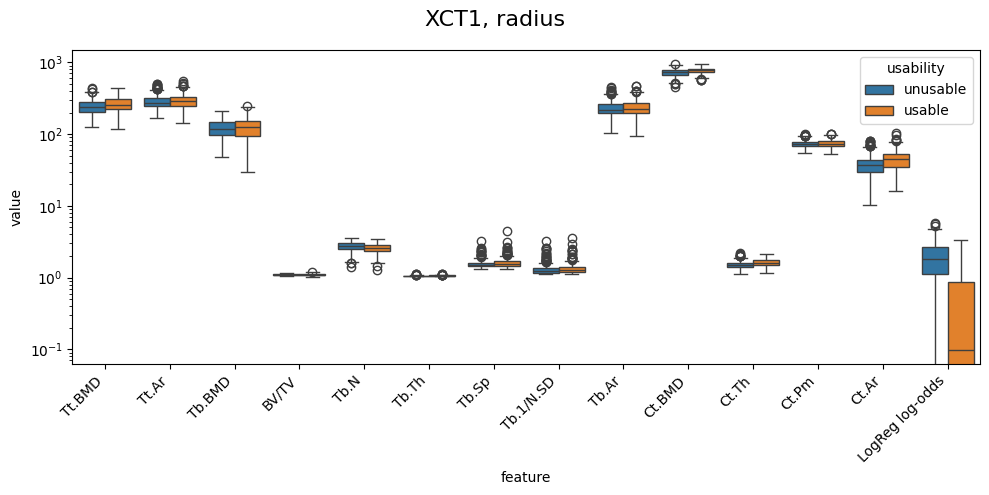

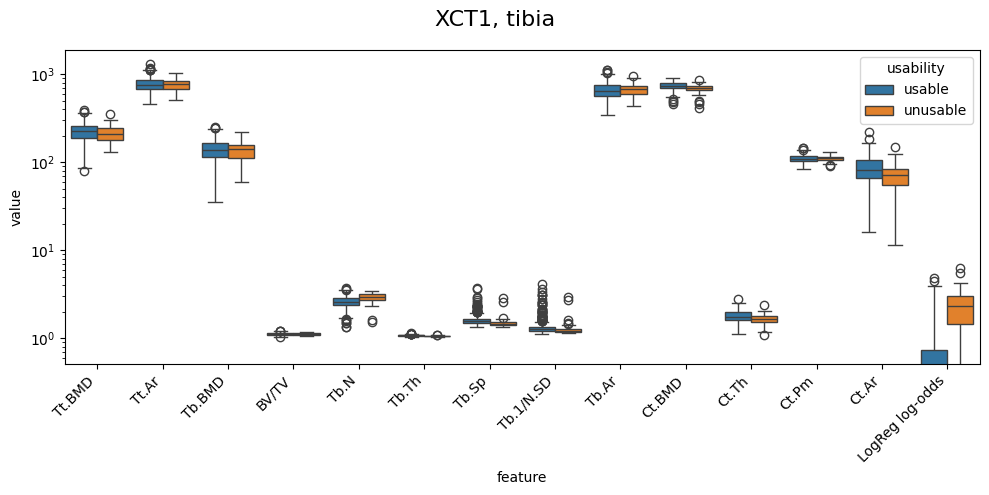

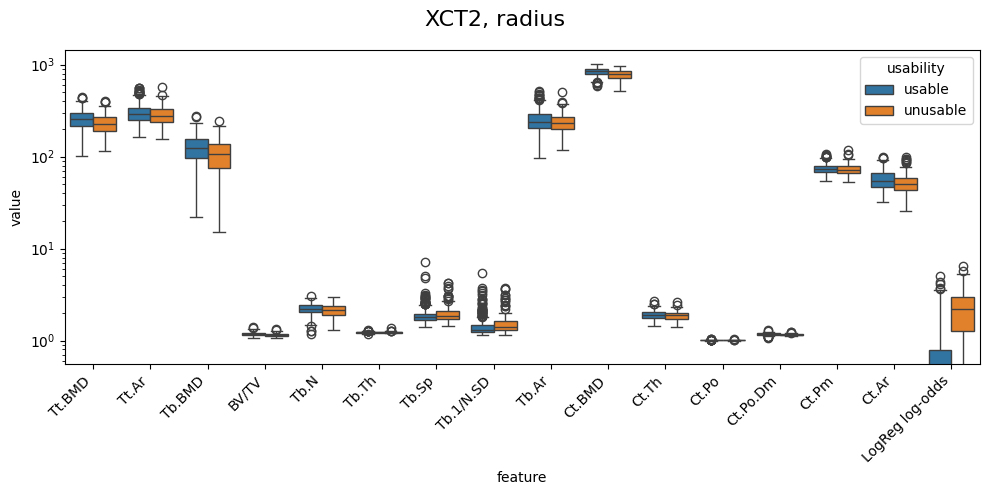

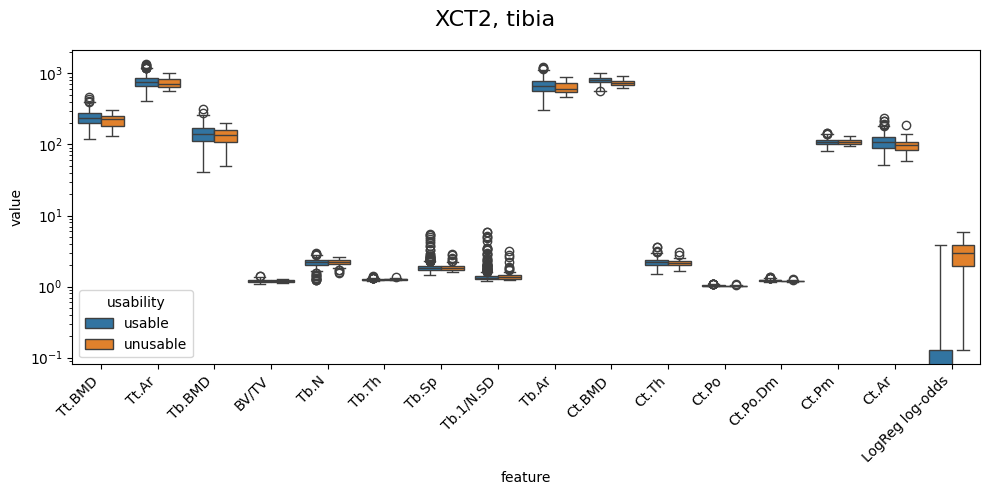

In [10]:
for xct in data_filtered['XCT'].unique():
    for bone in data_filtered['bone'].unique():
        data_xct = data_filtered[(data_filtered['XCT'] == xct) & (data_filtered['bone'] == bone)]
        fig = plt.figure(figsize=(10, 5))
        # if xct1, skip Ct.Po and Ct.Po.Dm
        if xct == 'XCT1':
            # copy pred_cols_radius and remove Ct.Po and Ct.Po.Dm
            pred_cols = pred_cols_radius.copy()
            pred_cols.remove('Ct.Po')
            pred_cols.remove('Ct.Po.Dm')

        else:
            pred_cols = pred_cols_radius
        
        p_vals = []
        all_cols = pred_cols + ['LogReg log-odds']
        for i, col in enumerate(all_cols):
            _, p = mannwhitneyu(data_xct[data_xct['usability'] == 'usable'][col], data_xct[data_xct['usability'] == 'unusable'][col])
            # check class of p
            if p > 0.05:
                p_str = ""
            elif p > 0.01:
                p_str = "*"
            elif p > 0.001:
                p_str = "**"
            else:
                p_str = "***"
            p_vals.append(p)
        
        # melt down dataframe to long format for seaborn
        data_xct = data_xct.melt(id_vars=['usability'], value_vars=all_cols, var_name='feature', value_name='value')
        data_xct['value'] = data_xct['value'] + 1 # add 1 to avoid log(0) errors

        sns.boxplot(data=data_xct, x="feature", y='value', hue='usability')
        # above each boxplot, add the p-value
        for i, p in enumerate(p_vals):
            ax.text(i, data_xct['value'].max() * 2, p_str, ha='center', va='bottom', fontsize=12)
        ax.set_ylabel("")
        ax.set_xlabel("")
        # rotate x labels
        plt.xticks(rotation=45, ha='right')
        plt.yscale('log')
        ax.set_title(f"{col} {p_str}", loc='left')


        # set overarching title
        plt.suptitle(f"{xct}, {bone}", fontsize=16)
        plt.tight_layout()
        plt.show()

## ROC curves per significant param

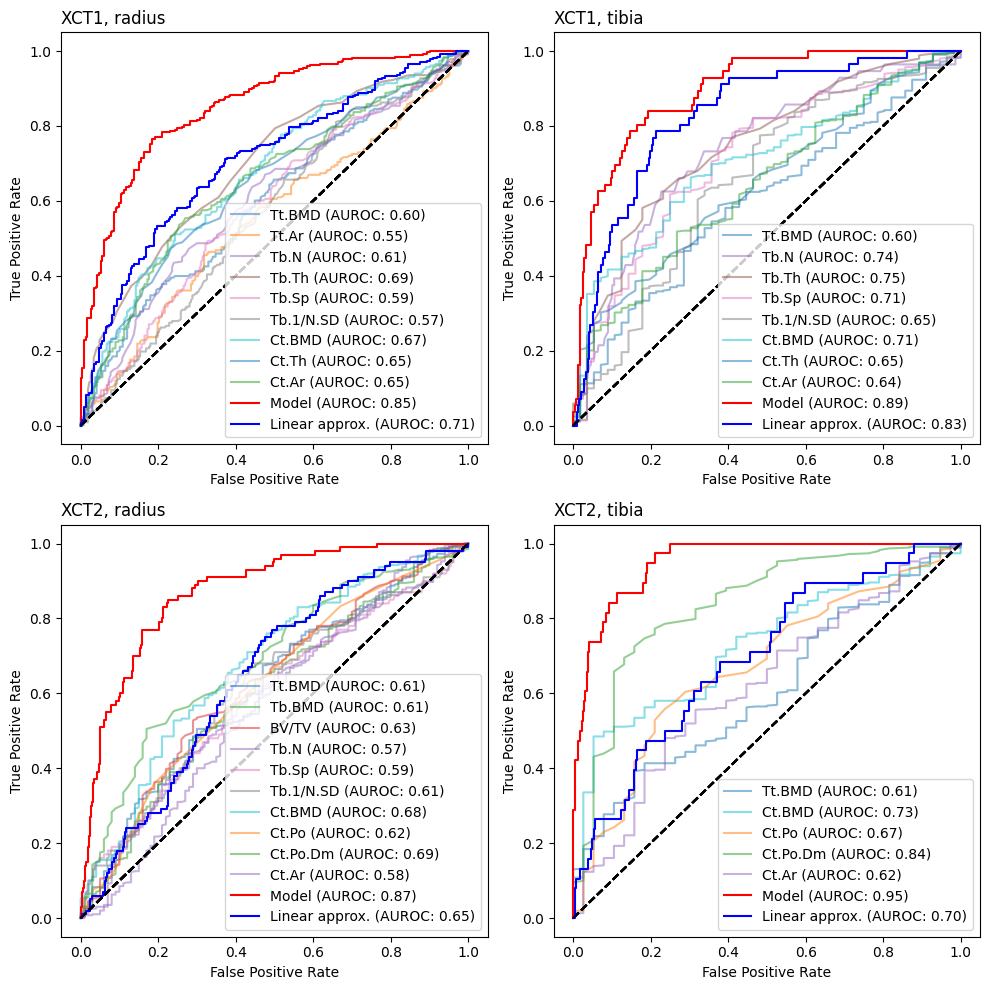

In [21]:
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(figsize=(10, 10), ncols=2, nrows=2)
for c, xct in enumerate(data_filtered['XCT'].unique()):
    for r, bone in enumerate(data_filtered['bone'].unique()):
        data_xct = data_filtered[(data_filtered['XCT'] == xct) & (data_filtered['bone'] == bone)]
        # if xct1, skip Ct.Po and Ct.Po.Dm
        if xct == 'XCT1':
            # copy pred_cols_radius and remove Ct.Po and Ct.Po.Dm
            pred_cols = pred_cols_radius.copy()
            pred_cols.remove('Ct.Po')
            pred_cols.remove('Ct.Po.Dm')

        else:
            pred_cols = pred_cols_radius
        ax = axes[c, r]  # get the current subplot
        for i, col in enumerate(pred_cols + ['LogReg log-odds', 'CombinedScore']):
            if data_xct[col].isna().all():
                continue
            _, p = mannwhitneyu(data_xct[data_xct['usability'] == 'usable'][col], data_xct[data_xct['usability'] == 'unusable'][col])
            # check class of p
            if p > 0.05:
                continue
            # do ROC curve
            if col == 'LogReg log-odds':
                color = 'red'
                fpr, tpr, _ = roc_curve(data_xct['usability'].map({'usable': 0, 'unusable': 1}), data_xct[col])
                ax.plot(fpr, tpr, label=f"Model (AUROC: {auc(fpr, tpr):.2f})", color=color, alpha=1)
            elif col == 'CombinedScore':
                color = 'blue'
                fpr, tpr, _ = roc_curve(data_xct['usability'].map({'usable': 0, 'unusable': 1}), data_xct[col])
                ax.plot(fpr, tpr, label=f"Linear approx. (AUROC: {auc(fpr, tpr):.2f})", color=color, alpha=1)
            elif col == 'ScoreByXCT':
                color = 'green'
                fpr, tpr, _ = roc_curve(data_xct['usability'].map({'usable': 0, 'unusable': 1}), data_xct[col])
                ax.plot(fpr, tpr, label=f"{col} (AUROC: {auc(fpr, tpr):.2f})", color=color, alpha=1)
            else:
                fpr, tpr, _ = roc_curve(data_xct['usability'].map({'usable': 1, 'unusable': 0}), data_xct[col])
                auc_score = auc(fpr, tpr)
                if auc_score < 0.5:
                    fpr, tpr, _ = roc_curve(data_xct['usability'].map({'usable': 0, 'unusable': 1}), data_xct[col])
                color = sns.color_palette()[i % len(sns.color_palette())]
                ax.plot(fpr, tpr, label=f"{col} (AUROC: {auc(fpr, tpr):.2f})", color=color, alpha=0.5)
            ax.plot([0, 1], [0, 1], 'k--')
            ax.legend(loc='lower right')
            ax.set_title(f"{xct}, {bone}", loc='left')
            ax.set_xlabel("False Positive Rate")
            ax.set_ylabel("True Positive Rate")
# set overarching title
plt.tight_layout()
plt.savefig("figures/roc_curves.pdf")
plt.show()

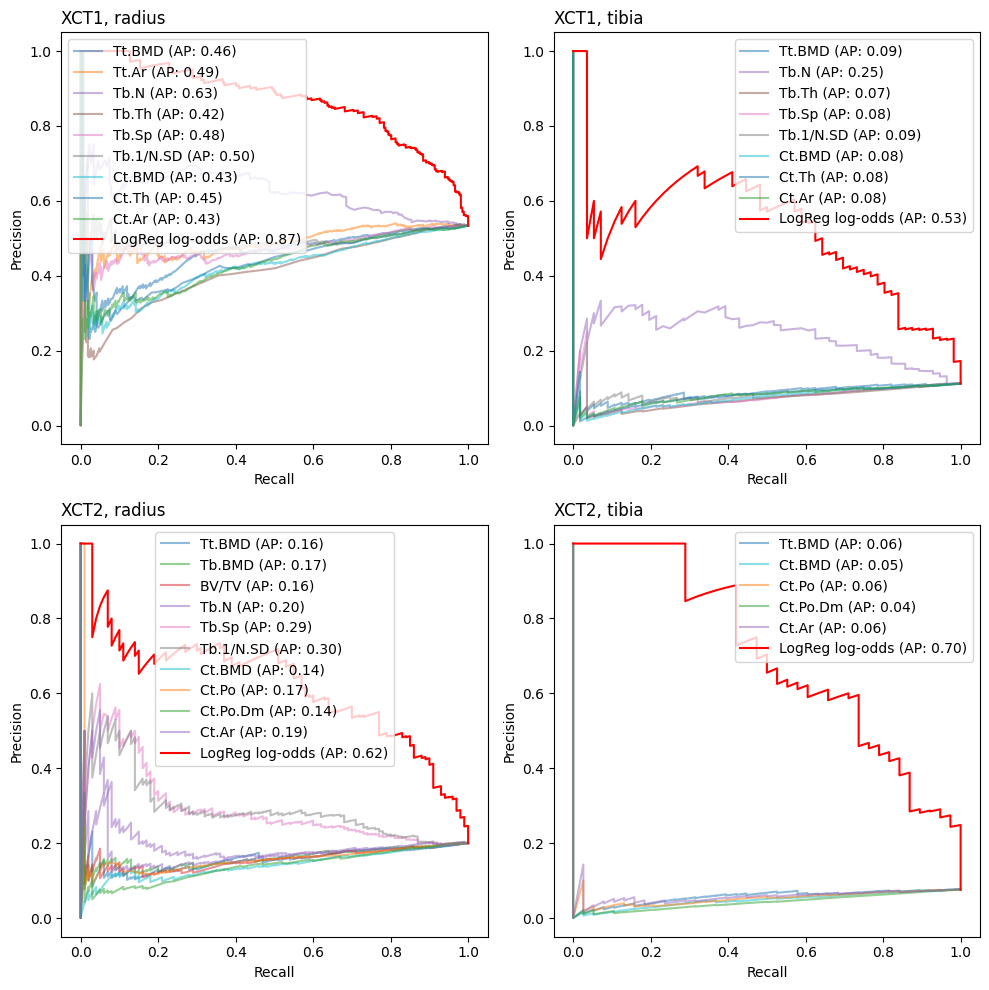

In [12]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(figsize=(10, 10), ncols=2, nrows=2)
for c, xct in enumerate(data_filtered['XCT'].unique()):
    for r, bone in enumerate(data_filtered['bone'].unique()):
        data_xct = data_filtered[(data_filtered['XCT'] == xct) & (data_filtered['bone'] == bone)]
        # if xct1, skip Ct.Po and Ct.Po.Dm
        if xct == 'XCT1':
            # copy pred_cols_radius and remove Ct.Po and Ct.Po.Dm
            pred_cols = pred_cols_radius.copy()
            pred_cols.remove('Ct.Po')
            pred_cols.remove('Ct.Po.Dm')

        else:
            pred_cols = pred_cols_radius
        ax = axes[c, r]  # get the current subplot
        for i, col in enumerate(pred_cols + ['LogReg log-odds']):
            if data_xct[col].isna().all():
                continue
            _, p = mannwhitneyu(data_xct[data_xct['usability'] == 'usable'][col], data_xct[data_xct['usability'] == 'unusable'][col])
            # check class of p
            if p > 0.05:
                continue
            # do ROC curve
            if col == 'LogReg log-odds':
                color = 'red'
                precision, recall, _ = precision_recall_curve(
                    data_xct['usability'].map({'usable': 0, 'unusable': 1}),
                    data_xct[col]
                )
                ap = average_precision_score(
                    data_xct['usability'].map({'usable': 0, 'unusable': 1}),
                    data_xct[col]
                )
                ax.plot(recall, precision, label=f"{col} (AP: {ap:.2f})", color=color, alpha=1)
            else:
                precision, recall, _ = precision_recall_curve(
                    data_xct['usability'].map({'usable': 0, 'unusable': 1}),
                    data_xct[col]
                )
                ap = average_precision_score(
                    data_xct['usability'].map({'usable': 0, 'unusable': 1}),
                    data_xct[col]
                )
                color = sns.color_palette()[i % len(sns.color_palette())]
                ax.plot(recall, precision, label=f"{col} (AP: {ap:.2f})", color=color, alpha=0.5)

        ax.legend()
        ax.set_title(f"{xct}, {bone}", loc='left')
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
# set overarching title
plt.tight_layout()
plt.show()

In [ ]:
### THIS BLOCK IS FOR THE PATIENT DATA ###
data = pd.read_excel("data/Gradings XLH + TIO.xlsx", sheet_name="XCT1" if OLDER_MACHINE else "XCT2")

radius_rows = data['Site1'].str.contains('Radius')
tibia_rows = data['Site1'].str.contains('Tibia')

pred_cols = ['Tt.BMD', 'Tt.Ar', 'Tb.BMD', 'BV/TV', 'Tb.N', 'Tb.Th', 'Tb.Sp', 'Tb.1/N.SD', 'Tb.Ar', 'Ct.BMD', 'Ct.Th', 'Ct.Po', 'Ct.Po.Dm', 'Ct.Pm', 'Ct.Ar']
if OLDER_MACHINE:
    pred_cols.remove('Ct.Po')
    pred_cols.remove('Ct.Po.Dm')
col_map_xct2 = {'Tb.1/N.SD1': 'Tb.1/N.SD', 'Tb.Sp1': 'Tb.Sp', 'Tb.Th1': 'Tb.Th', 'Tb.N1': 'Tb.N', 'Tb.Ar1': 'Tb.Ar', 'Tb.BV/TV1': 'BV/TV', 
           'Ct.Pm1': 'Ct.Pm', 'Ct.Th1': 'Ct.Th', 'Ct.Ar1': 'Ct.Ar', 'Tot.vBMD1': 'Tt.BMD', 'Tb.vBMD1': 'Tb.BMD', 'Ct.vBMD1': 'Ct.BMD', 
           'Ct.Po1': 'Ct.Po', 'Ct.Po.Dm1': 'Ct.Po.Dm', 'Tt.Ar1': 'Tt.Ar', }

col_map_xct1 = {'tTb.1/N.SD1': 'Tb.1/N.SD', 'tTb.Sp1': 'Tb.Sp', 'tTb.Th1': 'Tb.Th', 'tTb.N1': 'Tb.N', 'TrabArea1': 'Tb.Ar', 'CortArea1': 'Ct.Ar',
                'tBV/TV1': 'BV/TV', 'Ct.Pm1': 'Ct.Pm','Ct.Th1': 'Ct.Th', 'D100-1': 'Tt.BMD', 'Tt.Ar1': 'Tt.Ar','Dtrab1': 'Tb.BMD', 'Dcomp1': 'Ct.BMD',}

col_map = col_map_xct1 if OLDER_MACHINE else col_map_xct2

data = data.rename(columns=col_map)

measured_data = data[pred_cols]

if BONE == 'tibia':
    test_data = measured_data[tibia_rows].reset_index(drop=True)
else:
    test_data = measured_data[radius_rows].reset_index(drop=True)

test_data